# Calculating neuron tuning to stim1 identity

Plan is to look at neuron firing rate during stim1 encoding period
- calculate whether there is a significant difference between fr when stim1 is +1 versus -1

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



In [2]:
delay = 400
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/neuraldata_raw_delay400.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/bhvdata_raw_delay400.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/timingdata_raw_delay400.mat']


## Plotting

### First just plot bhv

<Axes: title={'center': 'Performance by Trial Type'}, xlabel='Trial Type', ylabel='Performance'>

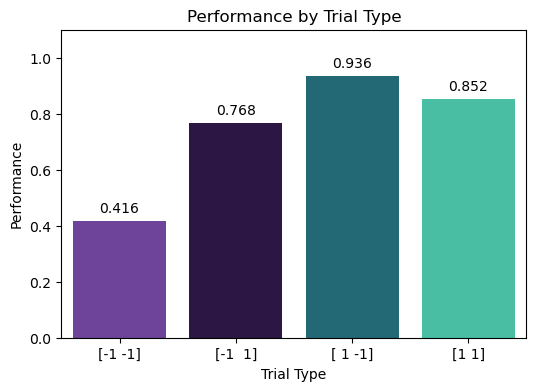

In [5]:
bhv.plot_trial_performance(model_dirs[0], condn_phrase, 150)

<Axes: title={'center': 'Performance by Trial Type'}, xlabel='Trial Type', ylabel='Performance'>

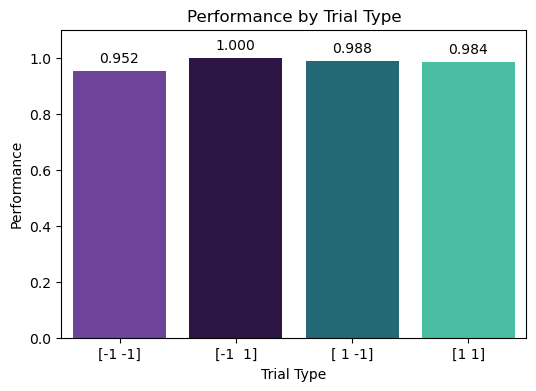

In [ ]:
importlib.reload(bhv)

bhv.plot_trial_performance(model_name, condn_phrase, condn_num)

In [5]:
# get tuning, one-line function

tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)

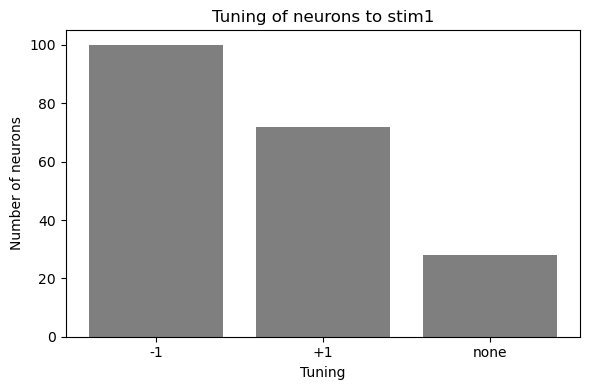

In [6]:
# plot bar graph of num neurons tuned to what

fig, ax = plt.subplots(figsize=(6,4))
x_labels = ['-1','+1','none']
x = np.arange(len(x_labels))
n_tuned = np.zeros(len(x_labels))
tuning_options = [-1, 1, np.nan]
for i, tuning_option in enumerate(tuning_options):
    n_tuned[i] = np.sum(tuning == tuning_option)
    if np.isnan(tuning_option):
        n_tuned[i] = np.sum(np.isnan(tuning))
ax.bar(x, n_tuned, color='black', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Number of neurons')
ax.set_xlabel('Tuning')
ax.set_title('Tuning of neurons to stim1')
plt.tight_layout()
plt.show()


[80. 49. 26.]
[20. 23.  2.]


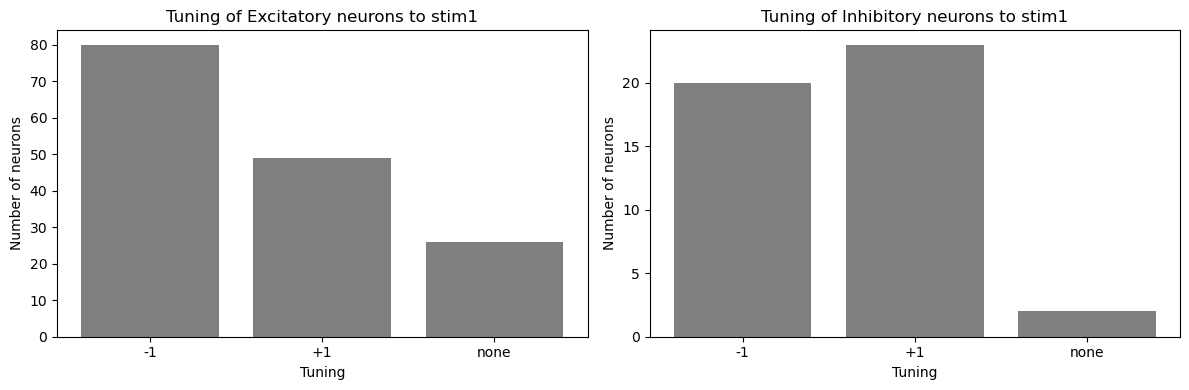

In [7]:
# split by exc/inh

# load exc/inh labels
exc_ind, inh_ind = ld.get_celltype_label(model_name)

# split tuning by exc/inh
fig, ax = plt.subplots(1,2,figsize=(12,4))
neur_type = ['Excitatory', 'Inhibitory']
for j, cell_type in enumerate([exc_ind, inh_ind]):
    x_labels = ['-1','+1','none']
    x = np.arange(len(x_labels))
    n_tuned = np.zeros(len(x_labels))
    tuning_options = [-1, 1, np.nan]
    for i, tuning_option in enumerate(tuning_options):
        n_tuned[i] = np.sum(tuning[cell_type] == tuning_option)
        if np.isnan(tuning_option):
            n_tuned[i] = np.sum(np.isnan(tuning[cell_type]))
    print(n_tuned)
    ax[j].bar(x, n_tuned, color='black', alpha=0.5)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels(x_labels)
    ax[j].set_ylabel('Number of neurons')
    ax[j].set_xlabel('Tuning')
    ax[j].set_title(f'Tuning of {neur_type[j]} neurons to stim1')
plt.tight_layout()
plt.show()